In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
df_main = pd.read_csv('../data/cleaned/analysis_data.csv')
fuel_subsidy_usd_col = 'fuel_subsidy_usd_million'
fuel_subsidy_pct_col = 'fuel_subsidy_gdp'

In [3]:
country_subsidy_profiles = (df_main
                               .groupby('country')
                               .agg({
                                   'fuel_subsidy_gdp': 'mean',
                                   'fuel_subsidy_usd_million': 'sum',
                                   'gdp': 'mean'
                               })
                               .reset_index())

In [4]:
country_subsidy_profiles

,country,fuel_subsidy_gdp,fuel_subsidy_usd_million,gdp
0,Afghanistan,0.102286,735.338963,4.078431e+10
1,Albania,0.337725,1317.278909,2.406177e+10
2,Algeria,3.349375,237631.818445,4.030310e+11
3,Angola,1.219099,24663.434871,9.979623e+10
4,Argentina,1.516023,163665.204087,6.971394e+11
...,...,...,...,...
158,Venezuela,5.806505,254585.484207,3.645908e+11
159,Vietnam,0.610775,53312.005667,4.317543e+11
160,Yemen,0.662875,8839.295788,8.032479e+10
161,Zambia,1.609929,10878.565213,3.895613e+10


## Fuel Subsidies as a DiD Interaction

A carbon tax and a fuel subsidy move the effective fossil-fuel price in opposite directions, so large subsidies should blunt the tax. We test `post_carbon_tax x fuel_subsidy_gdp` in the DiD with country + year fixed effects and clustered SEs, and trace the implied tax effect across subsidy levels.

In [6]:
import statsmodels.formula.api as smf

# Fuel subsidies as a moderator of the carbon tax. Use the validated schema/controls.
df = pd.read_csv('../data/cleaned/final_analysis_data.csv')
y = 'co2_per_capita_future_trend'
base_controls = ('log_gdp + log_population + trade_openness '
                 '+ natural_resource_rents_per_gdp + fossil_pct_filled')
need = [y, 'post_carbon_tax', 'fuel_subsidy_gdp', 'log_gdp', 'log_population',
        'trade_openness', 'natural_resource_rents_per_gdp', 'fossil_pct_filled']
d = df.dropna(subset=need)
print(f"Sample: {len(d)} obs, {int(d['post_carbon_tax'].sum())} treated\n")

# subsidy as a plain control, then interacted with the treatment
m0 = smf.ols(f"{y} ~ post_carbon_tax + fuel_subsidy_gdp + {base_controls} + C(year) + C(country)",
             data=d).fit(cov_type='cluster', cov_kwds={'groups': d['country']})
print(f"baseline ATT (subsidy as control): {m0.params['post_carbon_tax']:+.4f} (p={m0.pvalues['post_carbon_tax']:.3f})\n")

m1 = smf.ols(f"{y} ~ post_carbon_tax * fuel_subsidy_gdp + {base_controls} + C(year) + C(country)",
             data=d).fit(cov_type='cluster', cov_kwds={'groups': d['country']})
for term in ['post_carbon_tax', 'fuel_subsidy_gdp', 'post_carbon_tax:fuel_subsidy_gdp']:
    print(f"{term:34} {m1.params[term]:+.4f}  (SE {m1.bse[term]:.4f}, p={m1.pvalues[term]:.3f})")

for q in [0.1, 0.5, 0.9]:
    s = d['fuel_subsidy_gdp'].quantile(q)
    eff = m1.params['post_carbon_tax'] + m1.params['post_carbon_tax:fuel_subsidy_gdp'] * s
    print(f"  implied tax effect at subsidy p{int(q*100)} ({s:.2f}% GDP): {eff:+.4f}")

Sample: 1489 obs, 342 treated



baseline ATT (subsidy as control): -0.0161 (p=0.732)



post_carbon_tax                    -0.0604  (SE 0.0611, p=0.323)
fuel_subsidy_gdp                   -0.0049  (SE 0.0095, p=0.610)
post_carbon_tax:fuel_subsidy_gdp   +0.0766  (SE 0.0736, p=0.298)
  implied tax effect at subsidy p10 (0.00% GDP): -0.0604
  implied tax effect at subsidy p50 (0.29% GDP): -0.0383
  implied tax effect at subsidy p90 (2.13% GDP): +0.1027


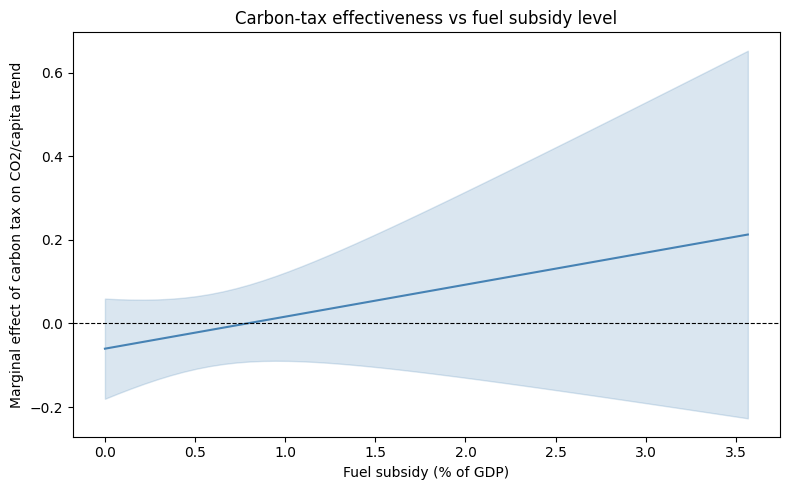

In [7]:
# Marginal effect of the carbon tax as a function of fuel subsidy level (delta-method CI)
sub = np.linspace(d['fuel_subsidy_gdp'].quantile(0.05), d['fuel_subsidy_gdp'].quantile(0.95), 50)
b, bi = m1.params['post_carbon_tax'], m1.params['post_carbon_tax:fuel_subsidy_gdp']
cov = m1.cov_params()
var = (cov.loc['post_carbon_tax', 'post_carbon_tax']
       + sub**2 * cov.loc['post_carbon_tax:fuel_subsidy_gdp', 'post_carbon_tax:fuel_subsidy_gdp']
       + 2 * sub * cov.loc['post_carbon_tax', 'post_carbon_tax:fuel_subsidy_gdp'])
eff = b + bi * sub
se = np.sqrt(var)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sub, eff, color='steelblue')
ax.fill_between(sub, eff - 1.96 * se, eff + 1.96 * se, alpha=0.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Fuel subsidy (% of GDP)')
ax.set_ylabel('Marginal effect of carbon tax on CO2/capita trend')
ax.set_title('Carbon-tax effectiveness vs fuel subsidy level')
plt.tight_layout()
plt.savefig('../outputs/fuel_subsidy_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

## Fuel Subsidy Interaction Results

In the subsample with subsidy data (1,489 obs, 342 treated) the baseline tax effect is weak (-0.016, p=0.73) — these countries are a lower-effect subset. The interaction `post_carbon_tax x fuel_subsidy_gdp = +0.077 (p=0.30)` is in the hypothesized direction: larger fuel subsidies blunt the carbon tax. The implied marginal effect moves from about -0.06 at low subsidies to +0.10 at high subsidies (~2% of GDP), but the interaction is not statistically significant. Suggestive evidence that subsidies and taxes work against each other, limited by the smaller sample — a question to resolve properly in Phase 2.